In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [70]:
#pip install wandb

In [71]:
'''import wandb

wandb.init(
    project="22f3000241-t22026"
    
)
'''

'import wandb\n\nwandb.init(\n    project="22f3000241-t22026"\n    \n)\n'

In [72]:
import matplotlib.pyplot as plt


In [73]:
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')

In [74]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [75]:
print(train_df.shape)
print(test_df.shape)

(2000, 8)
(500, 7)


In [76]:
print(f'train columns: {train_df.columns}')
print(f'test columns: {test_df.columns}')

train columns: Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')
test columns: Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E'], dtype='object')


In [77]:
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [78]:
test_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

# Answer Label Distribution

In [79]:
train_df['answer'].describe()

count     2000
unique       5
top          B
freq       490
Name: answer, dtype: object

In [80]:
answer_count = train_df['answer'].value_counts()
answer_count

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [81]:
percentages = (train_df['answer'].value_counts()/len(train_df))*100
percentages


answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64

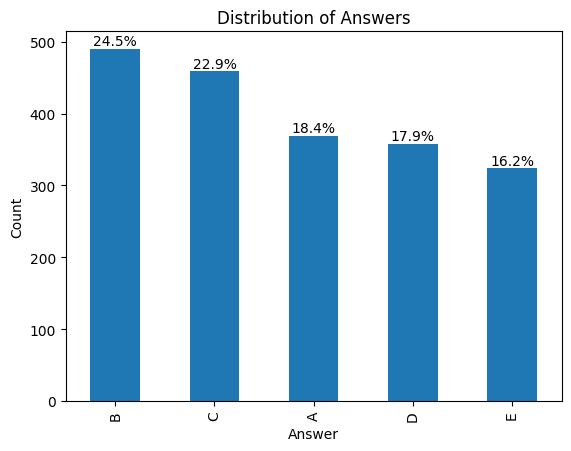

In [82]:
ax = answer_count.plot(kind='bar')
for i, p in enumerate(percentages):
    ax.text(i, answer_count.iloc[i] + 5, f'{p:.1f}%', ha='center')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.title('Distribution of Answers')
plt.show()

# Understanding Prompts

In [83]:
train_df['prompt'].str.len()

0       142
1        43
2       182
3       129
4       110
       ... 
1995     72
1996    104
1997     93
1998    266
1999    140
Name: prompt, Length: 2000, dtype: int64

In [84]:
train_df['prompt'].describe()

count                                                  2000
unique                                                 1758
top       Choose the correct answer: What is the main se...
freq                                                      4
Name: prompt, dtype: object

In [85]:
print(f'Total number of duplicates present in prompt : {train_df['prompt'].duplicated().sum()}')

Total number of duplicates present in prompt : 242


In [86]:
print(f'Total number of unique prompts : {train_df['prompt'].nunique()}')

Total number of unique prompts : 1758


In [87]:
train_df[train_df['prompt'].duplicated()].head()

,id,prompt,A,B,C,D,E,answer
112,113,Select the most accurate option: What are the ...,"They are unknown, but possibilities include la...",They are known to be black holes and Preon stars.,They are only MACHOs.,They are clusters of brown dwarfs.,They are new particles such as RAMBOs.,A
120,121,Pick the best possible answer: What is the met...,8 times more than the Sun,8 times less than the Sun,13 light years away from Earth,Unknown,Equal to the Sun,B
209,210,Select the most accurate option: What is the r...,The surface charge on a conductor depends on t...,The surface charge on a conductor depends on t...,The surface charge on a conductor depends on t...,The surface charge on a conductor depends on t...,The surface charge on a conductor depends on t...,D
238,239,Choose the correct answer: What is water hamme...,Water hammer is a type of water turbine used i...,Water hammer is a type of air trap or standpip...,Water hammer is a type of plumbing tool used t...,Water hammer is a type of water pump used to b...,Water hammer is a loud banging noise resemblin...,E
258,259,Identify the correct statement: What is the ef...,"An electric field, precisely aligned with the ...","A magnetic field, randomly aligned with the sp...","A magnetic field, precisely aligned with the s...","A gravitational field, randomly aligned with t...","A gravitational field, precisely aligned with ...",C


# OPTIONS

In [88]:
len(train_df)

2000

In [89]:
train_df['id']

0          1
1          2
2          3
3          4
4          5
        ... 
1995    1996
1996    1997
1997    1998
1998    1999
1999    2000
Name: id, Length: 2000, dtype: int64

In [90]:
options=['A','B','C','D']

In [91]:
options=['A','B','C','D']

avg_lengths = []

for option in options:
    avg_lengths.append(train_df[option].str.len().mean())

print(avg_lengths)
    

[np.float64(164.0915), np.float64(166.6165), np.float64(167.227), np.float64(162.5635)]


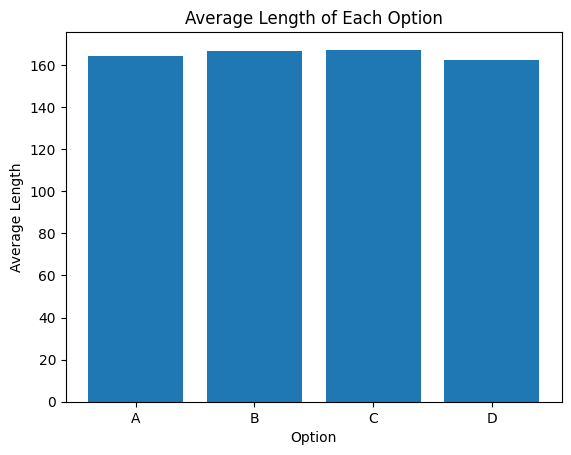

In [92]:

plt.bar(options, avg_lengths)
plt.xlabel("Option")
plt.ylabel("Average Length")
plt.title("Average Length of Each Option")
plt.show()

In [93]:
train_df['correct_len'] = train_df.apply(
    lambda row: len(row[row['answer']]),
    axis=1
)
correct_len = train_df['correct_len'].mean()
correct_len
print(f'Average of correct answer length: {correct_len:.2f}')

Average of correct answer length: 181.88


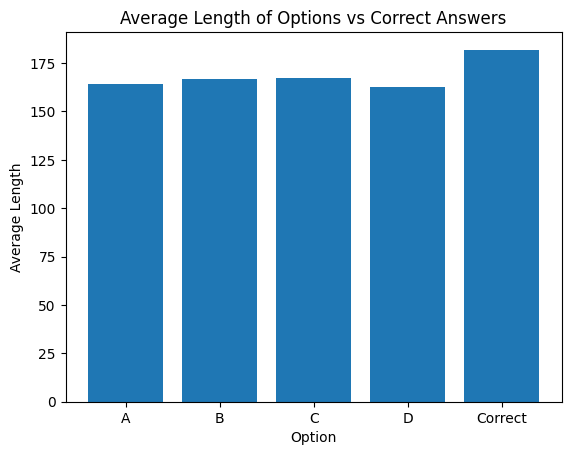

In [94]:
avg_correct = train_df['correct_len'].mean()

plt.bar(options + ['Correct'], avg_lengths + [avg_correct])
plt.xlabel('Option')
plt.ylabel('Average Length')
plt.title('Average Length of Options vs Correct Answers')
plt.show()

# Test Data

In [95]:
train_prompt=set(train_df['prompt'])


In [96]:
test_df['in_train'] = test_df['prompt'].isin(train_prompt)
print(f'No of questions present in train dataset which is also present in the test dataset : {test_df['in_train'].sum()} out of {len(test_df)}') 
print(f'In Percentage : {test_df['in_train'].mean()*100}%')



No of questions present in train dataset which is also present in the test dataset : 268 out of 500
In Percentage : 53.6%


In [97]:
lookup = dict(zip(train_df['prompt'], train_df['answer']))
test_df['known_answer'] = test_df['prompt'].map(lookup)


In [98]:
print(test_df[['id', 'prompt', 'known_answer']].dropna())

      id                                             prompt known_answer
0      1  Pick the best possible answer: What is the rel...            A
1      2  What is the estimated redshift of CEERS-93316,...            B
3      4  What is the significance of the redshift-dista...            E
4      5  What is the Landau-Lifshitz-Gilbert equation u...            C
7      8  What are the four qualitative levels of crysta...            B
..   ...                                                ...          ...
493  494  What is the relationship between the complete ...            D
494  495  What is the main focus of cryogenic and noble ...            A
495  496     What are the constituents of cold dark matter?            A
496  497  Pick the best possible answer: What is a plane...            C
499  500  What is the order parameter that breaks the el...            C

[268 rows x 3 columns]


# Baseline

In [99]:
test_df.columns

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'in_train', 'known_answer'], dtype='object')

In [100]:
test_df.head()

,id,prompt,A,B,C,D,E,in_train,known_answer
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...",True,A
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi...",True,B
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...,False,NaN
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,True,E
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,True,C


In [101]:
def make_pred(known_answer):
    freq_order = ['B', 'C', 'A', 'D', 'E']
    
    # Step 2: remove known_answer from the list
    remaining = [x for x in freq_order if x != known_answer ]
    
    # Step 3: take first 2
    top2 = remaining[:2]
    
    # Step 4: combine known_answer + top2, join with space
    pred = known_answer + " " + top2[0] + " " + top2[1]
    
    return pred

In [102]:
predictions = []
for i, row in test_df.iterrows():
    if pd.notna(row['known_answer']):
        pred = make_pred(row['known_answer'])
    else:
        pred = "B C A"
    predictions.append(pred)

In [103]:
len(predictions)

500

In [104]:
sub=pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')
sub

,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C
...,...,...
495,496,A B C
496,497,A B C
497,498,A B C
498,499,A B C


In [105]:
'''
submission = pd.DataFrame({
    "ID":test_df['id'],
    "Prediction":predictions
})

submission.to_csv("submission.csv",index=False)

print(submission.head())

'''

'\nsubmission = pd.DataFrame({\n    "ID":test_df[\'id\'],\n    "Prediction":predictions\n})\n\nsubmission.to_csv("submission.csv",index=False)\n\nprint(submission.head())\n\n'

### ***Model 1***

In [106]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')

In [107]:
dups=df_train[df_train.duplicated(subset='prompt',keep='first')]
print(len(dups))

242


In [108]:
df_dup = df_train.drop_duplicates(subset='prompt', keep='first').reset_index(drop=True)
print("Original:", len(df_train))       
print("After dup:", len(df_dup))  

Original: 2000
After dup: 1758


In [109]:
train_data, val_data = train_test_split(
    df_dup,
    test_size=0.2,
    stratify=df_dup['answer'],
    random_state=42
)

print("Train size:", len(train_data))
print("Val size:", len(val_data))

Train size: 1406
Val size: 352


In [110]:


all_text=[]
for _,row in train_data.iterrows():
    all_text.append(row['prompt'])
    all_text.append(row['A'])
    all_text.append(row['B'])
    all_text.append(row['C'])
    all_text.append(row['D'])
    all_text.append(row['E'])
    
    

In [111]:
import re
clean_text = []

for sentence in all_text:
    sentence = re.sub(r"[^\w\s]"," ",sentence.lower())
    clean_text.append(sentence)

In [112]:
from collections import Counter

text = " ".join(clean_text)

word_counts = Counter(text.split())

In [113]:
print(f'Total word length after splitting each words from the sentences : {len(word_counts)}')

Total word length after splitting each words from the sentences : 2978


In [114]:
# filtering out the rare words , rare ones is being replaced by UNK and PAD

vocab={'<PAD>': 0, '<UNK>': 1}

for word,counts in word_counts.items():
    if counts >= 3:
        vocab[word] = len(vocab)

print(len(vocab))


2959


In [115]:
# Encoding


def encode(text,vocab,max_len=128):
    text = re.sub(r"[^\w\s]", " ", text.lower())
    words = text.split()
    ids=[]
    for word in words:
        if word in vocab:
            ids.append(vocab[word])
        else:
            ids.append(vocab['<UNK>'])
    ids = ids[:max_len]
    ids =ids+[0]*(max_len - len(ids))
    return ids

In [116]:
test_sentence = "What is quantum entanglement stuff"
encoded = encode(test_sentence, vocab)
print(len(encoded))   
print(encoded[:10])   

128
[6, 7, 652, 1, 1, 0, 0, 0, 0, 0]


In [117]:
from torch.utils.data import Dataset


class MCQ(Dataset):
    def __init__(self,df,vocab):
        self.df = df 
        self.vocab = vocab 

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        row = self.df.iloc[idx]

        inputs=[]

        for option in ["A","B","C","D","E"]:
            text = row["prompt"] + " " + row[option]
            inputs.append(encode(text,self.vocab))
            
        label_map = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4}
        label = label_map[row['answer']]   
    
        return torch.tensor(inputs), torch.tensor(label)


In [118]:
train_dataset = MCQ(train_data,vocab)
val_dataset = MCQ(val_data,vocab)


In [119]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [120]:
inputs, labels = next(iter(train_loader))

In [121]:
inputs.shape

torch.Size([32, 5, 128])

In [122]:
inputs[0][0]

tensor([ 507,    3,  508,  509,   46,    6,    7, 1628,   13,  208, 1629, 1242,
         167,    3,  209,  212, 1628,   13,  208, 1629, 1242,    7,   18, 1030,
          27, 1630,  155, 1631,   26, 1632,  155, 1633, 1634, 1635,   26, 1636,
         208, 1629, 1242, 1637, 1002, 1030,    7,  493, 1638,   26, 1639,   21,
         172,  173, 1640,   23,   10, 1641, 1642, 1643,  195,   18,  822, 1644,
          18, 1137,    9, 1061,   21,   18,  471, 1384, 1645, 1242,  172,  173,
         409,  118,  150, 1646,  150, 1112, 1647,   62,    3, 1061,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

In [123]:
labels

tensor([0, 0, 0, 0, 1, 1, 1, 3, 2, 3, 3, 3, 3, 1, 4, 4, 4, 3, 0, 1, 3, 2, 4, 1,
        2, 0, 3, 2, 1, 3, 0, 3])

In [124]:
labels.shape

torch.Size([32])

In [125]:
len(vocab)

2959

### ***LSTM model*** ###

In [126]:
from torch.nn.utils.rnn import pack_padded_sequence

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embd_dim, hiddn_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embd_dim, padding_idx=0) 
        self.lstm = nn.LSTM(embd_dim, hiddn_dim, batch_first=True)
        self.fc   = nn.Linear(hiddn_dim, 1)

    def forward(self, x):
        scores = []
        for i in range(5):
            option = x[:, i, :]
            lengths = (option != 0).sum(dim=1).cpu().clamp(min=1) 
            embedded = self.embedding(option)
            packed = pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)  
            output, (hidden, cell) = self.lstm(packed)
            score = self.fc(hidden.squeeze(0))
            scores.append(score)
        return torch.cat(scores, dim=1)

In [127]:
model = LSTMModel(
    vocab_size=len(vocab),
    embd_dim=128,
    hiddn_dim=256
)

print(model)

LSTMModel(
  (embedding): Embedding(2959, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


In [128]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [129]:

#wandb.init(project="mcq-solver", name="lstm-baseline")

for epoch in range(10):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
    
    acc = correct / len(val_dataset)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Val Acc: {acc:.3f}")
    
 
'''    wandb.log({
        "epoch": epoch + 1,
        "train_loss": total_loss,
        "val_accuracy": acc
    })'''
    
     

#wandb.finish()



Epoch 1 | Loss: 55.493 | Val Acc: 0.688
Epoch 2 | Loss: 23.720 | Val Acc: 0.832
Epoch 3 | Loss: 9.885 | Val Acc: 0.940
Epoch 4 | Loss: 10.423 | Val Acc: 0.963
Epoch 5 | Loss: 8.182 | Val Acc: 0.912
Epoch 6 | Loss: 5.585 | Val Acc: 0.966
Epoch 7 | Loss: 2.582 | Val Acc: 0.969
Epoch 8 | Loss: 1.297 | Val Acc: 0.986
Epoch 9 | Loss: 1.164 | Val Acc: 0.969
Epoch 10 | Loss: 2.205 | Val Acc: 0.974


'    wandb.log({\n        "epoch": epoch + 1,\n        "train_loss": total_loss,\n        "val_accuracy": acc\n    })'

In [133]:
print(test_df.columns.tolist())

['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'in_train', 'known_answer']


In [141]:
def predict(model,test_df,vocab):
    model.eval()
    predictions=[]
    label_map={0:'A', 1:'B', 2:'C', 3:'D', 4:'E'}


    for _,row in test_df.iterrows():
        if pd.notna(row['known_answer']):
            
            known = row['known_answer']
            freq = [x for x in ['B','C','A','D','E'] if x!=known]
            pred = known + " " + freq[0]+ " "+freq[1]

        else:

            inputs=[]

            for opt in  ['A','B','C','D','E']:
                text = row['prompt'] + " " + row[opt]
                inputs.append(encode(text,vocab))


            inputs_tensor = torch.tensor([inputs])
            with torch.no_grad():
                scores = model(inputs_tensor)
                ranked = torch.argsort(scores, dim=1, descending=True)[0]
                
                
                top3 = [label_map[r.item()] for r in ranked[:3]]
                pred = " ".join(top3)
        predictions.append(pred)
        
    return predictions
                

In [142]:
predictions = predict(model, test_df, vocab)

submission = pd.DataFrame({
    'ID': test_df['id'],
    'Prediction': predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print("Total predictions:", len(predictions))

   ID Prediction
0   1      A B C
1   2      B C A
2   3      B E D
3   4      E B C
4   5      C B A
5   6      D A B
6   7      E D C
7   8      B C A
8   9      C B A
9  10      B C A
Total predictions: 500
